# Trion in a polarized cavity

This notebook introduces the source model for a four-level trion emitter coupled to a cavity with two polarization modes.

## Imports

We use the top-level ZPGenerator interface together with NumPy and Matplotlib for a small parameter sweep.

In [1]:
from zpgenerator import *
import numpy as np
import matplotlib.pyplot as plt

## Build the source

`Source.trion_cavity(...)` constructs an exact 16-dimensional model with two cavity outputs. Internally, the direct trion emission channels remain part of the physics model, but they are closed and masked in the final source component so that only the two cavity ports stay visible.

For the shared shorthand convention used below, `purcell_factor=10` means a symmetric total enhancement split across the two cavity modes. That is equivalent to `purcell_factor_h=5` and `purcell_factor_v=5`. If you want each mode to carry Purcell factor `10` individually, you can still set `purcell_factor_h=10` and `purcell_factor_v=10` explicitly.

In [2]:
pulse = Pulse.gaussian(parameters={'area': np.sqrt(2) * np.pi, 'width': 10})
source = Source.trion_cavity(pulse=pulse,
                             purcell_factor_h=5,
                             purcell_factor_v=5,
                             timescale=200,
                             regime=0.05,
                             parameters={'theta': 0, 'phi': 0})

## Relevant parameters

The cavity parameters are fully explicit. In particular, the two couplings and the two cavity resonances can be tuned independently.

In [3]:
source.default_parameters

{'cavity_h/resonance': 0.0,
 'cavity_h/dephasing': 0.0,
 'cavity_h/decay': 0.9999999999999998,
 'cavity_v/resonance': 0.0,
 'cavity_v/dephasing': 0.0,
 'cavity_v/decay': 0.9999999999999998,
 'trion/resonance': 0,
 'trion/Bx': 0,
 'trion/By': 0,
 'trion/Bz': 0,
 'trion/g_spin': 2,
 'trion/g_trion': 2,
 'trion/Bx_OH': 0,
 'trion/By_OH': 0,
 'trion/Bz_OH': 0,
 'trion/decay': 0.0005,
 'trion/theta_c': 0.7853981633974483,
 'trion/phi_c': -1.5707963267948966,
 'trion/dephasing': 0,
 'trion/dephasing_spin': 0,
 'trion/dephasing_trion': 0,
 'coupling_h': np.float64(0.03535533905932737),
 'coupling_v': np.float64(0.03535533905932737),
 'width': 10,
 'area': np.float64(4.442882938158366),
 'delay': 0,
 'detuning': 0,
 'phase': 0,
 'window': 6,
 'theta': 0,
 'phi': 0,
 'purcell_factor_h': 5,
 'purcell_factor_v': 5,
 'regime_h': 0.05,
 'regime_v': 0.05,
 'timescale': 200,
 'efficiency': 1}

## Symmetric cavity outputs

With the linear drive used here, both trion branches are addressed and the two cavity ports behave symmetrically. Under the shared shorthand convention used above, `purcell_factor=10` corresponds to `purcell_factor_h=5` and `purcell_factor_v=5`, which together give a combined cavity brightness close to `10/11` in this regime.

In [4]:
source.beta('cavity_h'), source.beta('cavity_v'), source.g2('cavity_h'), source.g2('cavity_v')

(0.45886519243727575,
 0.45886519243727575,
 0.036361388131825066,
 0.03636138779992477)

## Breaking the cavity symmetry

We can detune one cavity mode and compare the brightness of the two output ports. This is a simple way to explore the polarisation-selective cavity response.

In [5]:
detunings = np.linspace(-4, 4, 41)
beta_h = [source.beta('cavity_h', parameters={'cavity_h/resonance': d}) for d in detunings]
beta_v = [source.beta('cavity_v', parameters={'cavity_h/resonance': d}) for d in detunings]

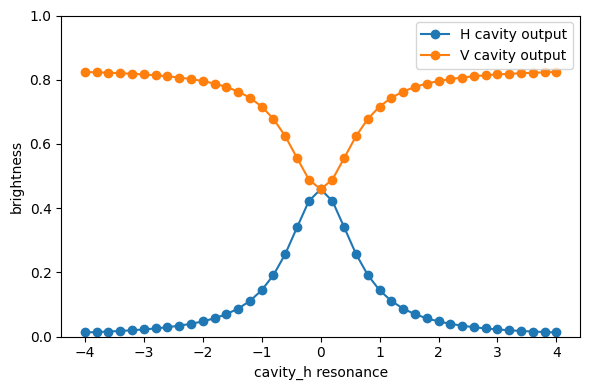

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(detunings, beta_h, 'o-', label='H cavity output')
plt.plot(detunings, beta_v, 'o-', label='V cavity output')
plt.xlabel('cavity_h resonance')
plt.ylabel('brightness')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

With no cavity splitting, the combined brightness from both ports is close to `10/11`. If we detune one cavity mode far away, the remaining resonant branch carries half of the symmetric total Purcell enhancement, so the collected brightness approaches `5/6`.

If you need a stronger single-mode contribution instead, you can still specify the per-mode parameters explicitly, for example `purcell_factor_h=10` and `purcell_factor_v=10`, rather than using the shared shorthand `purcell_factor=10`.

In [7]:
source.beta('cavity_h', parameters={'cavity_h/resonance': 20}) + \
source.beta('cavity_v', parameters={'cavity_h/resonance': 20})

0.8346414410822098

In [8]:
2.5/3.5

0.7142857142857143